# Swin-S per attack

Swin-S restricts attention to shifted windows and has no class token, so a trigger's tokens reach the decision through a different route than in ViT-B/16. The paper reports a mean over every implanted Swin model (`swin-and-robustness.ipynb`), and this notebook breaks it out by attack and by dataset, then sets the per-attack gain beside ViT's. It compares PSBD-TM against PSBD-RD on the models `scripts/paper/tab_swin.py` reads, the Swin models the ViT panel rule selects that are successful backdoors, at the adaptive rate rule and the headline quantile on the fractional PSU. It reads cached JSON only and runs in about 30 seconds.

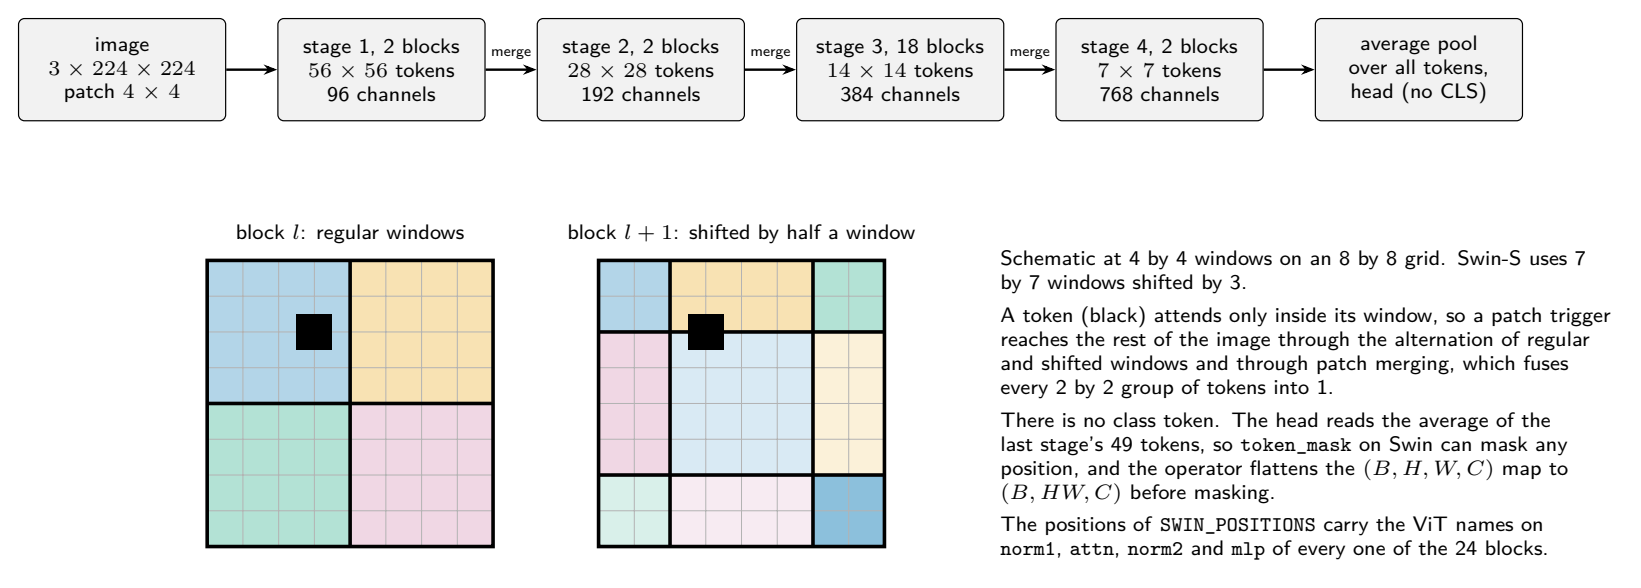

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import json
import logging
import warnings

logging.getLogger("lightning.fabric.utilities.seed").setLevel(logging.WARNING)
# torchvision's ToTensor deprecation fires once per dataset load and says nothing
# about the numbers below.
warnings.filterwarnings("ignore", message="The transform `ToTensor", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

import scripts.paper._style  # noqa: F401  the figure style every paper figure uses
from scripts.paper._common import word_list

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline


def macro(table, name):
    """1 value of paper/tables/<table>.macros.json, the string headline.tex prints."""
    with open(f"paper/tables/{table}.macros.json") as handle:
        sidecar = json.load(handle)
    value = sidecar["macros"][name]["value"]
    return value


def show_diagram(name, width=None):
    """Embed a TikZ diagram rendered by notebooks/figures/render.py."""
    display(Image(filename=f"notebooks/figures/{name}.png", width=width))

from defenses.decision import ADAPTIVE_SHIFT_TARGET, HEADLINE_QUANTILE, PUBLISHED_PLACEMENT, RECOMMENDED_PLACEMENT
from scripts.paper._common import (
    BOOTSTRAP_RESAMPLES,
    BOOTSTRAP_SEED,
    HEADLINE_KEY,
    OKABE_ITO,
    attack_label,
    bootstrap_ci,
    dataset_label,
    fmt,
    load_declaration,
)
from scripts.paper._style import TEXT_WIDTH, legend_above
from scripts.paper.tab_swin import HEADLINE_RULE, reading, swin_cells

show_diagram("swin_windows", width=900)

## The Swin models

Swin follows exactly the ViT panel rule: `scripts.paper._common.swin_coverage` applies the declaration of `configs/psbd_basis.json` to the Swin checkpoints with the benign Swin-S references and the coverage ledger's own verdicts, and the generator's `swin_cells` keeps the successful backdoors (`successful_2pt`) that carry a PSBD cache, so a model at a rate outside the panel, a non-canonical variant, a source-mapped TaCT model or a model that lost more clean accuracy than the headline bar allows is not read.

In [2]:
declaration = load_declaration("configs/psbd_basis.json")
cells = swin_cells("results", "checkpoints", declaration["asr_bar"])
assert str(len(cells)) == macro("swin", "SwinCells")

per_model = pd.DataFrame(
    [
        {
            "folder": cell["folder"],
            "attack": attack_label(cell["attack"]),
            "dataset": dataset_label(cell["dataset"]),
            "poison rate": cell["poison_rate"],
            "PSBD-TM": reading(cell["report"], RECOMMENDED_PLACEMENT, HEADLINE_RULE, HEADLINE_KEY, "auroc"),
            "PSBD-RD": reading(cell["report"], PUBLISHED_PLACEMENT, HEADLINE_RULE, HEADLINE_KEY, "auroc"),
        }
        for cell in cells
    ]
)
print(f"{len(cells)} implanted Swin models above the {declaration['asr_bar']} bar")
print(f"rule {HEADLINE_RULE}, threshold at the {HEADLINE_QUANTILE:.0%} clean-validation quantile")
per_model.groupby("dataset").size().rename("models")

65 implanted Swin models above the 0.85 bar
rule adaptive, threshold at the 25% clean-validation quantile


dataset
CIFAR-10         18
CIFAR-100        16
GTSRB            16
Tiny ImageNet    15
Name: models, dtype: int64

## Paired means per attack

A placement whose rate ladder never reaches the adaptive shift target has no reading on that model. The table counts those models per attack and computes each attack's means and gain over the models carrying both placements, so the 2 columns always average the same models. The gain carries a 95% bootstrap interval over the attack's models.

In [3]:
missing = per_model.groupby("attack")[["PSBD-TM", "PSBD-RD"]].agg(lambda column: column.isna().sum())
paired = per_model.dropna(subset=["PSBD-TM", "PSBD-RD"])

per_attack = paired.groupby("attack").agg(models=("PSBD-TM", "size"), tm=("PSBD-TM", "mean"), rd=("PSBD-RD", "mean"))
per_attack["gain"] = per_attack["tm"] - per_attack["rd"]
intervals = {attack: bootstrap_ci((rows["PSBD-TM"] - rows["PSBD-RD"]).tolist(), BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED) for attack, rows in paired.groupby("attack")}
per_attack["low"] = [intervals[a][0] for a in per_attack.index]
per_attack["high"] = [intervals[a][1] for a in per_attack.index]
per_attack["TM unreached"] = missing["PSBD-TM"]
per_attack["RD unreached"] = missing["PSBD-RD"]
per_attack = per_attack.sort_values("gain", ascending=False)

overall_gain = (paired["PSBD-TM"] - paired["PSBD-RD"]).mean()
assert fmt(overall_gain, signed=True) == macro("swin", "SwinGainRecommendedMinusPublished")
assert str(len(paired)) == macro("swin", "SwinGainRecommendedMinusPublishedN")
attacks_gaining = (per_attack["gain"] > 0).sum()
print(f"{len(paired)} of {len(per_model)} models carry both placements")
print(f"paired gain over every model {overall_gain:+.3f}, positive on {attacks_gaining} of {len(per_attack)} attacks")
print("models with no adaptive reading, per attack:", {a: dict(r) for a, r in missing[missing.sum(axis=1) > 0].iterrows()})
top_gains = per_attack.sort_values("gain", ascending=False).head(4)
rd_ahead = list(per_attack.index[per_attack["gain"] < 0])
unreached_tm = missing["PSBD-TM"][missing["PSBD-TM"] > 0]
models_by_attack_all = per_model.groupby("attack").size()
per_attack.round(3)

63 of 65 models carry both placements
paired gain over every model +0.096, positive on 3 of 6 attacks
models with no adaptive reading, per attack: {'TaCT': {'PSBD-TM': np.int64(2), 'PSBD-RD': np.int64(0)}}


,models,tm,rd,gain,low,high,TM unreached,RD unreached
attack,,,,,,,,
WaNet,8,0.944,0.615,0.329,0.152,0.507,0,0
BadNets,12,0.999,0.771,0.228,0.145,0.319,0,0
LF,12,0.978,0.880,0.098,0.033,0.172,0,0
Blend,12,0.996,0.998,-0.002,-0.007,0.002,0,0
BPP,12,0.980,0.997,-0.017,-0.050,0.001,0,0
Adaptive-Blend,7,0.899,0.938,-0.040,-0.125,0.005,0,0


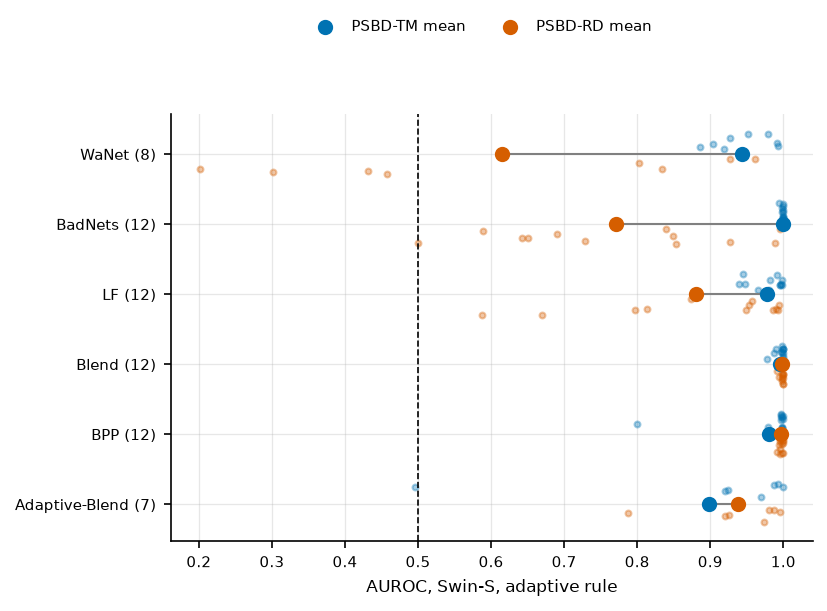

In [4]:
figure, axis = plt.subplots(figsize=(TEXT_WIDTH * 0.8, 0.45 * len(per_attack) + 1.0))
rows = np.arange(len(per_attack))  # (attacks,)
jitter = np.random.default_rng(0)

# Every model sits behind its attack's means as a faint point, so a mean over 2
# models cannot pass for a mean over 15.
for row_index, attack in enumerate(per_attack.index):
    models = paired[paired["attack"] == attack]
    offsets = jitter.uniform(-0.12, 0.12, size=len(models))  # (models,)
    axis.scatter(models["PSBD-RD"], row_index + 0.18 + offsets, color=OKABE_ITO[1], alpha=0.35, s=8)
    axis.scatter(models["PSBD-TM"], row_index - 0.18 + offsets, color=OKABE_ITO[0], alpha=0.35, s=8)

axis.hlines(rows, per_attack["rd"], per_attack["tm"], color="gray", linewidth=1.0)
axis.scatter(per_attack["tm"], rows, color=OKABE_ITO[0], s=40, zorder=3, label="PSBD-TM mean")
axis.scatter(per_attack["rd"], rows, color=OKABE_ITO[1], s=40, zorder=3, label="PSBD-RD mean")
axis.axvline(0.5, color="black", linewidth=0.8, linestyle="--")
axis.set_yticks(rows, labels=[f"{attack} ({n})" for attack, n in zip(per_attack.index, per_attack["models"])])
axis.invert_yaxis()
axis.set_xlabel("AUROC, Swin-S, adaptive rule")
legend_above(figure, [axis], columns=2)
plt.show()

In [5]:
display(Markdown(rf"""
Each row joins an attack's 2 means, with every model behind them as a faint point. The largest Swin gains are {word_list([f"{a} ({g:+.3f})" for a, g in top_gains["gain"].items()])}, with PSBD-RD near chance on some of those models while PSBD-TM stays close to 1. PSBD-RD is ahead on {word_list(rd_ahead)}, by at most {-per_attack.loc[rd_ahead, "gain"].min():.3f}. Both placements detect those attacks well. {int(unreached_tm.sum())} models have no PSBD-TM reading because its ladder never reached the {ADAPTIVE_SHIFT_TARGET} target (`\SwinShiftTargetUnreached`): {word_list([f"{n} of the {models_by_attack_all[a]} {a} models" for a, n in unreached_tm.items()])}, so an attack whose every model is unreached has no row here. The overall paired gain, {overall_gain:+.3f} over {len(paired)} models, is checked against `\SwinGainRecommendedMinusPublished`. The figure does not show the dataset, the next figure.
"""))


Each row joins an attack's 2 means, with every model behind them as a faint point. The largest Swin gains are WaNet (+0.329), BadNets (+0.228), LF (+0.098) and Blend (-0.002), with PSBD-RD near chance on some of those models while PSBD-TM stays close to 1. PSBD-RD is ahead on Blend, BPP and Adaptive-Blend, by at most 0.040. Both placements detect those attacks well. 2 models have no PSBD-TM reading because its ladder never reached the 0.8 target (`\SwinShiftTargetUnreached`): 2 of the 2 TaCT models, so an attack whose every model is unreached has no row here. The overall paired gain, +0.096 over 63 models, is checked against `\SwinGainRecommendedMinusPublished`. The figure does not show the dataset, the next figure.


## Gain per attack and dataset

The heatmap splits the paired gain of PSBD-TM over PSBD-RD by attack and dataset, so an attack whose gain comes from 1 dataset shows up as 1 dark cell.

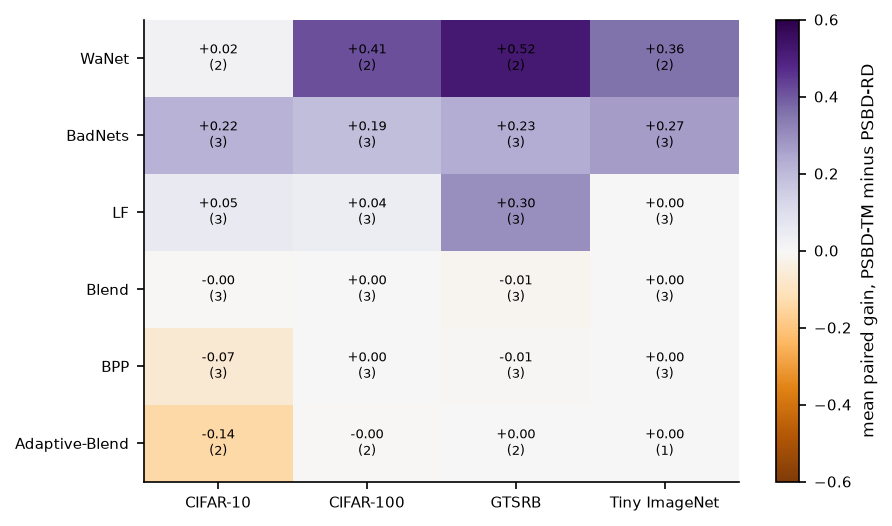

In [6]:
paired = paired.assign(gain=paired["PSBD-TM"] - paired["PSBD-RD"])
gain_grid = paired.pivot_table(index="attack", columns="dataset", values="gain", aggfunc="mean").reindex(per_attack.index)
count_grid = paired.pivot_table(index="attack", columns="dataset", values="gain", aggfunc="size").reindex(per_attack.index)
figure, axis = plt.subplots(figsize=(6.4, 4.0))
image = axis.imshow(gain_grid.to_numpy(dtype=float), cmap="PuOr", vmin=-0.6, vmax=0.6, aspect="auto")
for r in range(gain_grid.shape[0]):
    for c in range(gain_grid.shape[1]):
        value = gain_grid.iat[r, c]
        if not pd.isna(value):
            axis.text(c, r, f"{value:+.2f}\n({int(count_grid.iat[r, c])})", ha="center", va="center", fontsize=6)
axis.set_xticks(range(gain_grid.shape[1]), labels=gain_grid.columns)
axis.set_yticks(range(gain_grid.shape[0]), labels=gain_grid.index)
axis.grid(False)
figure.colorbar(image, ax=axis, label="mean paired gain, PSBD-TM minus PSBD-RD")
plt.show()
positive_everywhere = [a for a in gain_grid.index if (gain_grid.loc[a].dropna() > 0).all()]
largest_loss = gain_grid.stack().idxmin()
cells_small = int((count_grid.stack() <= 4).sum())

In [7]:
display(Markdown(rf"""
Purple is a gain for PSBD-TM and orange a gain for PSBD-RD, with the models behind each cell in brackets. The gain is positive on every dataset for {word_list(positive_everywhere)}. The largest loss is {largest_loss[0]} on {largest_loss[1]} ({gain_grid.loc[largest_loss]:+.2f}). The cells hold between {int(count_grid.min().min())} and {int(count_grid.max().max())} models, so a single cell is a small sample and the per-attack interval above is the better guide.
"""))


Purple is a gain for PSBD-TM and orange a gain for PSBD-RD, with the models behind each cell in brackets. The gain is positive on every dataset for WaNet, BadNets and LF. The largest loss is Adaptive-Blend on CIFAR-10 (-0.14). The cells hold between 1 and 3 models, so a single cell is a small sample and the per-attack interval above is the better guide.


## Swin against ViT, per attack

The last figure sets each attack's paired gain on Swin beside the same gain on the ViT headline panel (`scripts.paper.tab_staircase.panel_cells`), both with 95% bootstrap intervals. An attack that gains on both architectures is a property of the probe. An attack that gains on 1 only is a property of the architecture.

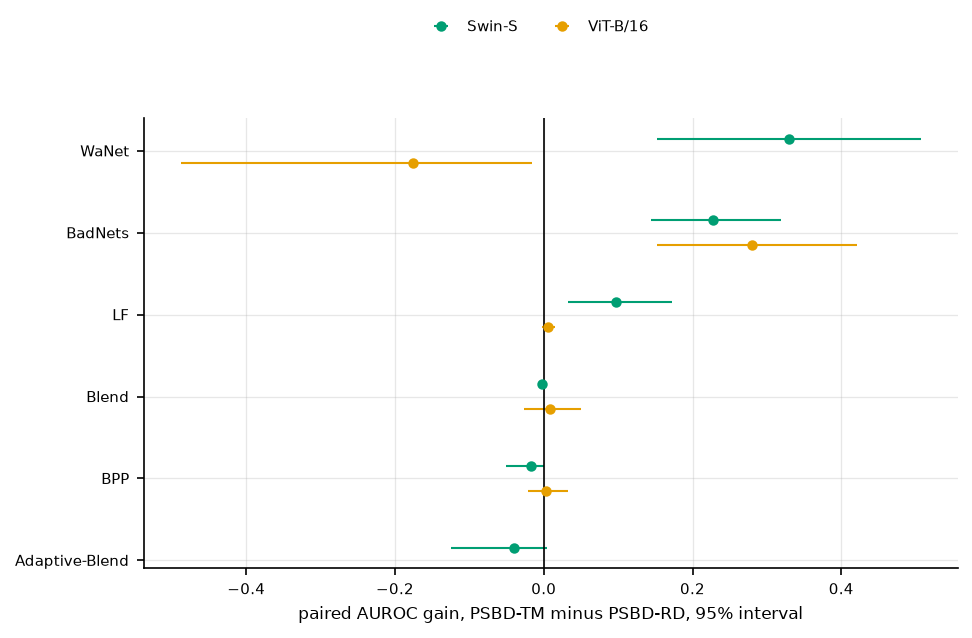

,Swin gain,Swin models,ViT gain,ViT models
attack,,,,
WaNet,0.329,8.0,-0.176,3.0
BadNets,0.228,12.0,0.280,12.0
LF,0.098,12.0,0.005,12.0
Blend,-0.002,12.0,0.008,12.0
BPP,-0.017,12.0,0.003,12.0
Adaptive-Blend,-0.040,7.0,NaN,NaN


In [8]:
from cli.compare_detectors import psbd_values
from scripts.paper._common import load_coverage
from scripts.paper.tab_staircase import panel_cells

vit_rows = []
for cell in panel_cells("results", load_coverage("results")):
    tm = psbd_values(cell["report"], RECOMMENDED_PLACEMENT, "adaptive")[HEADLINE_KEY]["auroc"]
    rd = psbd_values(cell["report"], PUBLISHED_PLACEMENT, "adaptive")[HEADLINE_KEY]["auroc"]
    vit_rows.append({"attack": attack_label(cell["attack"]), "gain": tm - rd})
vit = pd.DataFrame(vit_rows)
vit_gain = vit.groupby("attack")["gain"].agg(["mean", "size"])
vit_ci = {a: bootstrap_ci(rows["gain"].tolist(), BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED) for a, rows in vit.groupby("attack")}

attacks = list(per_attack.index)
figure, axis = plt.subplots(figsize=(7.0, 0.45 * len(attacks) + 1.2))
for offset, (label, means, ci, counts, color) in enumerate((
    ("Swin-S", per_attack["gain"], {a: (per_attack.loc[a, "low"], per_attack.loc[a, "high"]) for a in attacks}, per_attack["models"], OKABE_ITO[2]),
    ("ViT-B/16", vit_gain["mean"], vit_ci, vit_gain["size"], OKABE_ITO[4]),
)):
    shown = [a for a in attacks if a in means.index]
    positions = np.array([attacks.index(a) for a in shown]) + (offset - 0.5) * 0.3  # (attacks shown,)
    values = np.array([means[a] for a in shown])  # (attacks shown,)
    errors = np.array([[values[i] - ci[a][0], ci[a][1] - values[i]] for i, a in enumerate(shown)]).T  # (2, attacks shown)
    axis.errorbar(values, positions, xerr=errors, fmt="o", color=color, ms=4, lw=1, label=label)
axis.axvline(0, color="black", lw=0.8)
axis.set_yticks(range(len(attacks)), labels=attacks)
axis.invert_yaxis()
axis.set_xlabel("paired AUROC gain, PSBD-TM minus PSBD-RD, 95% interval")
legend_above(figure, [axis], columns=2)
plt.show()
both = pd.DataFrame({"Swin gain": per_attack["gain"], "Swin models": per_attack["models"], "ViT gain": vit_gain["mean"], "ViT models": vit_gain["size"]})
parted = [a for a in both.dropna().index if (both.loc[a, "Swin gain"] - both.loc[a, "ViT gain"]) > 0.05]
no_swin_row = sorted(set(vit_gain.index) - set(per_attack.index))
no_vit_row = sorted(set(per_attack.index) - set(vit_gain.index))
both.reindex(attacks).round(3)

In [9]:
display(Markdown(rf"""
BadNets gains on both architectures ({both.loc["BadNets", "Swin gain"]:+.3f} on Swin, {both.loc["BadNets", "ViT gain"]:+.3f} on ViT), the patch-trigger effect `mechanism.ipynb` traced on ViT. The architectures part, with Swin favoring PSBD-TM by more than 0.05, on {word_list(parted)}. On ViT PSBD-RD detects WaNet best of every defense (`detectors-per-attack.ipynb`, gain {both.loc["WaNet", "ViT gain"]:+.3f} here), while on Swin the WaNet gain is {both.loc["WaNet", "Swin gain"]:+.3f}. No SIG model is a successful backdoor on either architecture, so SIG has no row. {word_list(no_swin_row)} {"has" if len(no_swin_row) == 1 else "have"} no Swin row (above), and {word_list(no_vit_row)} {"has" if len(no_vit_row) == 1 else "have"} no ViT row because {"it does" if len(no_vit_row) == 1 else "they do"} not clear the ViT headline panel. With few models on WaNet and TaCT the intervals are wide or undefined, so the architecture difference on those attacks is an observation, not a settled result.
"""))


BadNets gains on both architectures (+0.228 on Swin, +0.280 on ViT), the patch-trigger effect `mechanism.ipynb` traced on ViT. The architectures part, with Swin favoring PSBD-TM by more than 0.05, on LF and WaNet. On ViT PSBD-RD detects WaNet best of every defense (`detectors-per-attack.ipynb`, gain -0.176 here), while on Swin the WaNet gain is +0.329. No SIG model is a successful backdoor on either architecture, so SIG has no row. TaCT has no Swin row (above), and Adaptive-Blend has no ViT row because it does not clear the ViT headline panel. With few models on WaNet and TaCT the intervals are wide or undefined, so the architecture difference on those attacks is an observation, not a settled result.
